In [1]:
# Fitabase Data Analysis Project

In [2]:
!pip install pandas numpy matplotlib seaborn plotly squarify

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(style="whitegrid")  # Clean, professional default style


In [4]:

daily_activity = pd.read_csv("../data/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv")
daily_activity.head()


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [5]:
daily_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDate              940 non-null    object 
 2   TotalSteps                940 non-null    int64  
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    int64  
 11  FairlyActiveMinutes       940 non-null    int64  
 12  LightlyActiveMinutes      940 non-null    int64  
 13  SedentaryMinutes          940 non-null    int64  
 14  Calories  

In [6]:
daily_activity['ActivityDate'] = pd.to_datetime(daily_activity['ActivityDate'])

In [7]:
daily_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Id                        940 non-null    int64         
 1   ActivityDate              940 non-null    datetime64[ns]
 2   TotalSteps                940 non-null    int64         
 3   TotalDistance             940 non-null    float64       
 4   TrackerDistance           940 non-null    float64       
 5   LoggedActivitiesDistance  940 non-null    float64       
 6   VeryActiveDistance        940 non-null    float64       
 7   ModeratelyActiveDistance  940 non-null    float64       
 8   LightActiveDistance       940 non-null    float64       
 9   SedentaryActiveDistance   940 non-null    float64       
 10  VeryActiveMinutes         940 non-null    int64         
 11  FairlyActiveMinutes       940 non-null    int64         
 12  LightlyActiveMinutes  

In [10]:
daily_activity.isna().sum()

Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64

In [11]:
daily_activity.duplicated().sum()

np.int64(0)

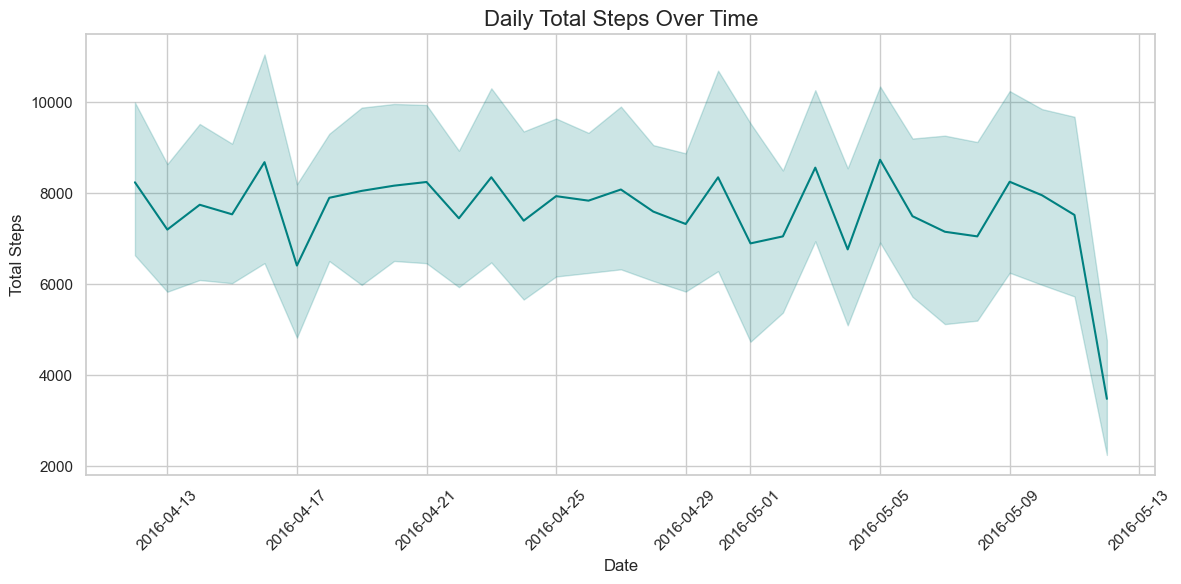

In [13]:

plt.figure(figsize=(12,6))
sns.lineplot(data=daily_activity, x='ActivityDate', y='TotalSteps', color='teal')
plt.title("Daily Total Steps Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Total Steps")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


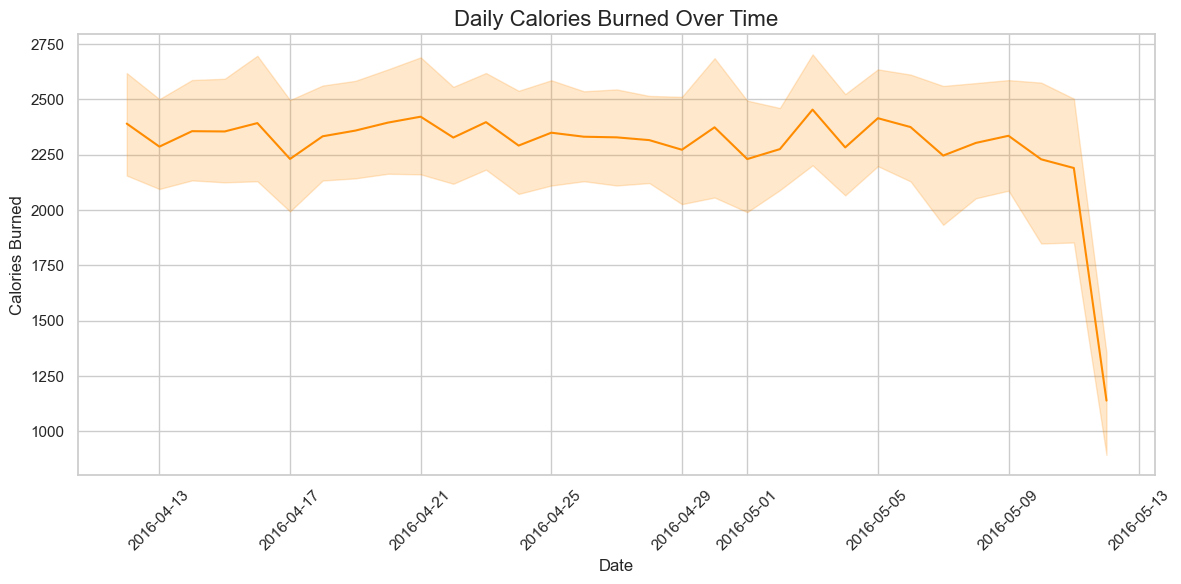

In [14]:

plt.figure(figsize=(12,6))
sns.lineplot(data=daily_activity, x='ActivityDate', y='Calories', color='darkorange')
plt.title("Daily Calories Burned Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Calories Burned")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


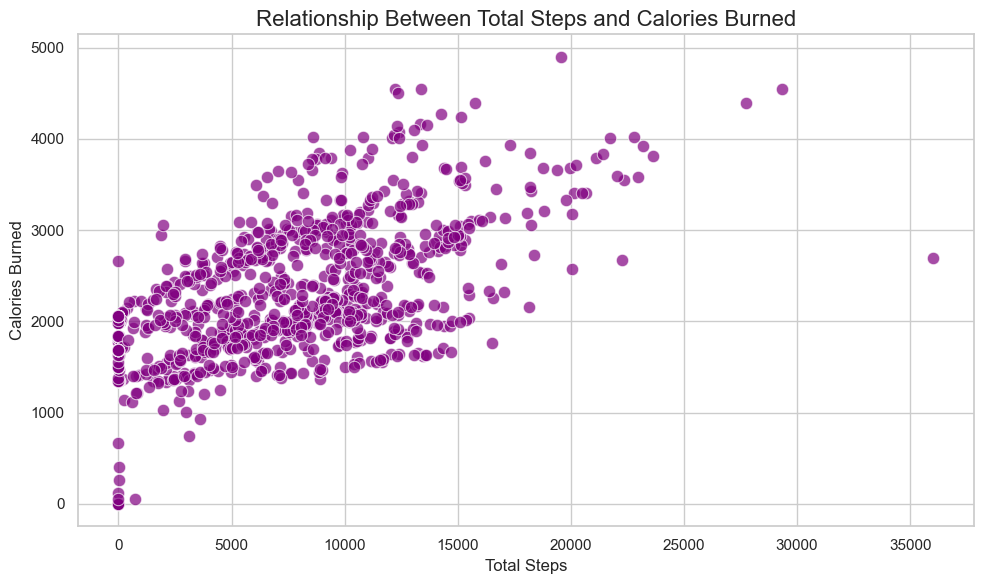

In [15]:

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=daily_activity,
    x='TotalSteps',
    y='Calories',
    s=80,
    color='purple',
    alpha=0.7
)
plt.title("Relationship Between Total Steps and Calories Burned", fontsize=16)
plt.xlabel("Total Steps")
plt.ylabel("Calories Burned")
plt.tight_layout()
plt.show()


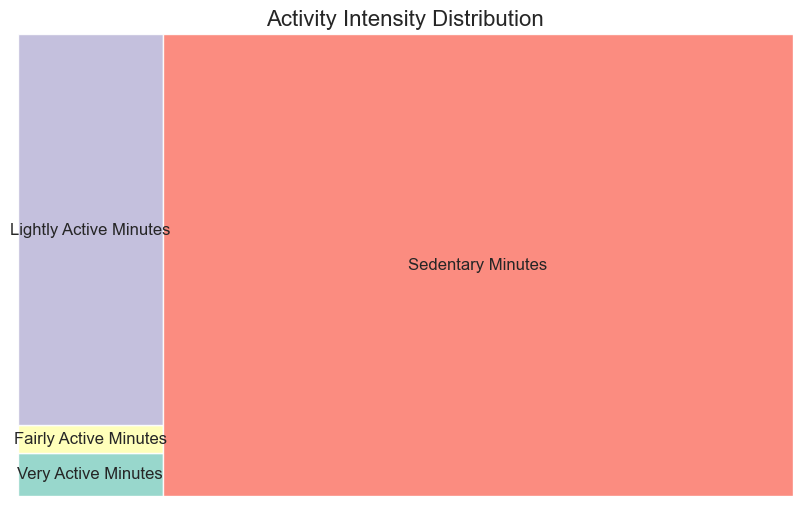

In [16]:

import squarify

activity_breakdown = {
    'Very Active Minutes': daily_activity['VeryActiveMinutes'].sum(),
    'Fairly Active Minutes': daily_activity['FairlyActiveMinutes'].sum(),
    'Lightly Active Minutes': daily_activity['LightlyActiveMinutes'].sum(),
    'Sedentary Minutes': daily_activity['SedentaryMinutes'].sum()
}

plt.figure(figsize=(10,6))
squarify.plot(
    sizes=activity_breakdown.values(),
    label=activity_breakdown.keys(),
    color=sns.color_palette("Set3"),
    alpha=0.9
)
plt.title("Activity Intensity Distribution", fontsize=16)
plt.axis('off')
plt.show()


In [18]:

plt.savefig("../outputs/charts/daily_steps_over_time.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

In [19]:
plt.savefig("../outputs/charts/activity_intensity_treemap.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [20]:
plt.savefig("../outputs/charts/daily_calories_over_time.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [21]:
plt.savefig("../outputs/charts/steps_vs_calories.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>


### Daily Steps – First Impressions

Looking at the daily step counts over time, a few things stand out:

- The user is generally staying above 7,000–9,000 steps per day, which is fairly consistent.
- There are a couple of noticeable dips, particularly around the end of the date range.
- There are also peak days where steps exceed 12,000, suggesting more active days or specific workouts.

This gives a good early picture of overall activity levels before diving deeper.



### Daily Calories Burned – What Does This Tell Us?

Calories burned follow a similar pattern to steps, with steady day‑to‑day levels and a few higher‑activity days.

On days with noticeably higher step counts, calories burned also rise, which makes sense physiologically.

There are a few lower‑calorie days too, which may correspond to rest days or less movement.


In [22]:

sleep = pd.read_csv("../data/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/sleepDay_merged.csv")
sleep.head()


,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712


In [24]:
sleep['SleepDay'] = pd.to_datetime(sleep['SleepDay'], format='%m/%d/%Y %I:%M:%S %p')

In [25]:
sleep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413 entries, 0 to 412
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Id                  413 non-null    int64         
 1   SleepDay            413 non-null    datetime64[ns]
 2   TotalSleepRecords   413 non-null    int64         
 3   TotalMinutesAsleep  413 non-null    int64         
 4   TotalTimeInBed      413 non-null    int64         
dtypes: datetime64[ns](1), int64(4)
memory usage: 16.3 KB


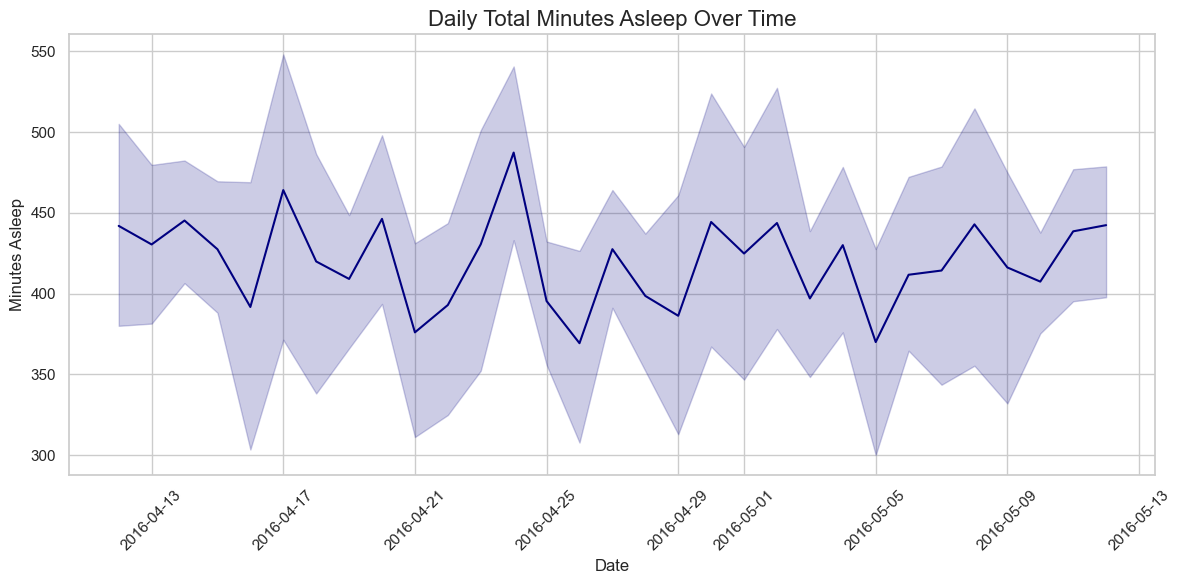

In [26]:

plt.figure(figsize=(12,6))
sns.lineplot(data=sleep, x='SleepDay', y='TotalMinutesAsleep', color='navy')
plt.title("Daily Total Minutes Asleep Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Minutes Asleep")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [27]:
plt.savefig("../outputs/charts/daily_sleep_minutes.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

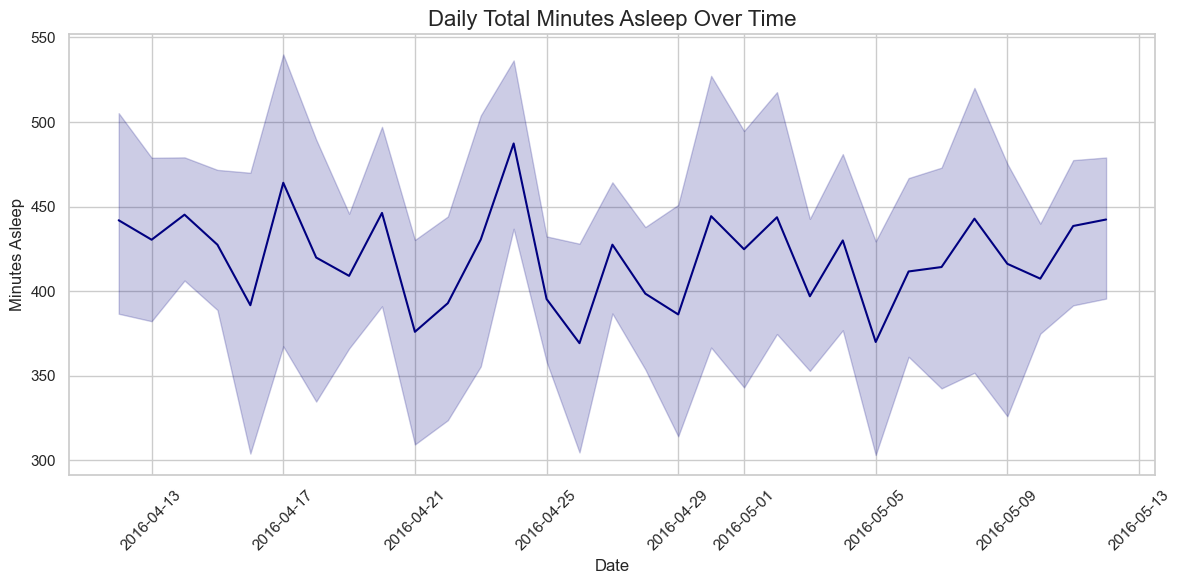

In [28]:

plt.figure(figsize=(12,6))
sns.lineplot(data=sleep, x='SleepDay', y='TotalMinutesAsleep', color='navy')
plt.title("Daily Total Minutes Asleep Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Minutes Asleep")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [29]:
plt.savefig("../outputs/charts/daily_sleep_minutes.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>


### Sleep Duration – First Impressions

The chart shows that total minutes asleep varies noticeably from day to day. 
Some nights reach 7–8 hours of sleep, while others fall significantly lower. 
This suggests that sleep habits are less consistent than activity levels.

This variation can influence energy levels, recovery, and overall wellbeing. 
Later in the analysis, it may be useful to compare sleep patterns with step counts 
or calories burned to see whether poor sleep leads to quieter activity days.


In [30]:

# Make a copy to avoid any confusion
activity = daily_activity.copy()
sleep_data = sleep.copy()

# Rename sleep date column to match activity date column
sleep_data.rename(columns={'SleepDay': 'ActivityDate'}, inplace=True)

# Merge on ActivityDate and Id
merged = pd.merge(activity, sleep_data, on=['Id', 'ActivityDate'], how='inner')

merged.head()


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,1,327,346
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,2,384,407
2,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,1,412,442
3,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,2,340,367
4,1503960366,2016-04-17,9705,6.48,6.48,0.0,3.19,0.78,2.51,0.0,38,20,164,539,1728,1,700,712


In [31]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413 entries, 0 to 412
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Id                        413 non-null    int64         
 1   ActivityDate              413 non-null    datetime64[ns]
 2   TotalSteps                413 non-null    int64         
 3   TotalDistance             413 non-null    float64       
 4   TrackerDistance           413 non-null    float64       
 5   LoggedActivitiesDistance  413 non-null    float64       
 6   VeryActiveDistance        413 non-null    float64       
 7   ModeratelyActiveDistance  413 non-null    float64       
 8   LightActiveDistance       413 non-null    float64       
 9   SedentaryActiveDistance   413 non-null    float64       
 10  VeryActiveMinutes         413 non-null    int64         
 11  FairlyActiveMinutes       413 non-null    int64         
 12  LightlyActiveMinutes  

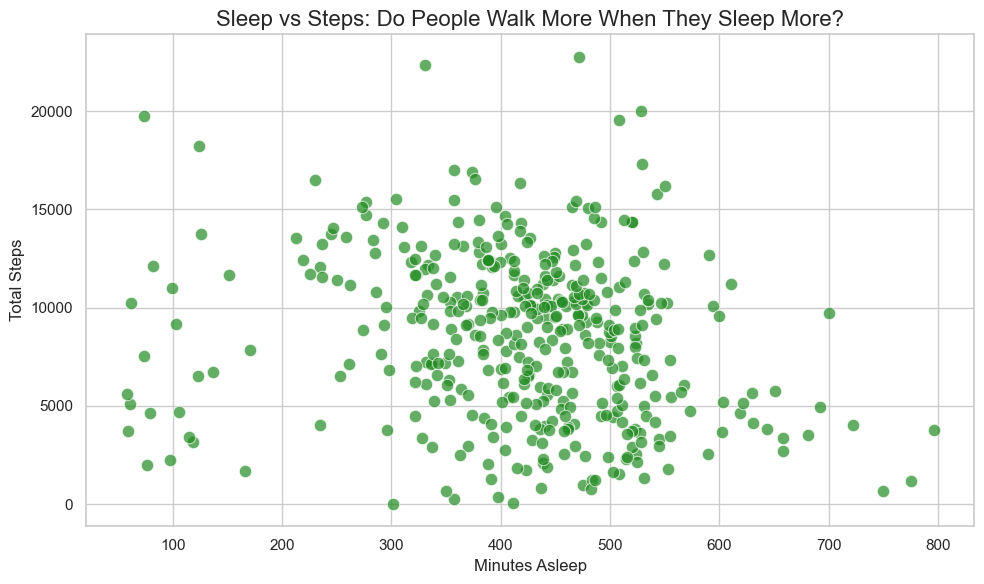

In [32]:

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=merged,
    x='TotalMinutesAsleep',
    y='TotalSteps',
    color='forestgreen',
    s=80,
    alpha=0.7
)
plt.title("Sleep vs Steps: Do People Walk More When They Sleep More?", fontsize=16)
plt.xlabel("Minutes Asleep")
plt.ylabel("Total Steps")
plt.tight_layout()
plt.show()


In [33]:
plt.savefig("../outputs/charts/sleep_vs_steps.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

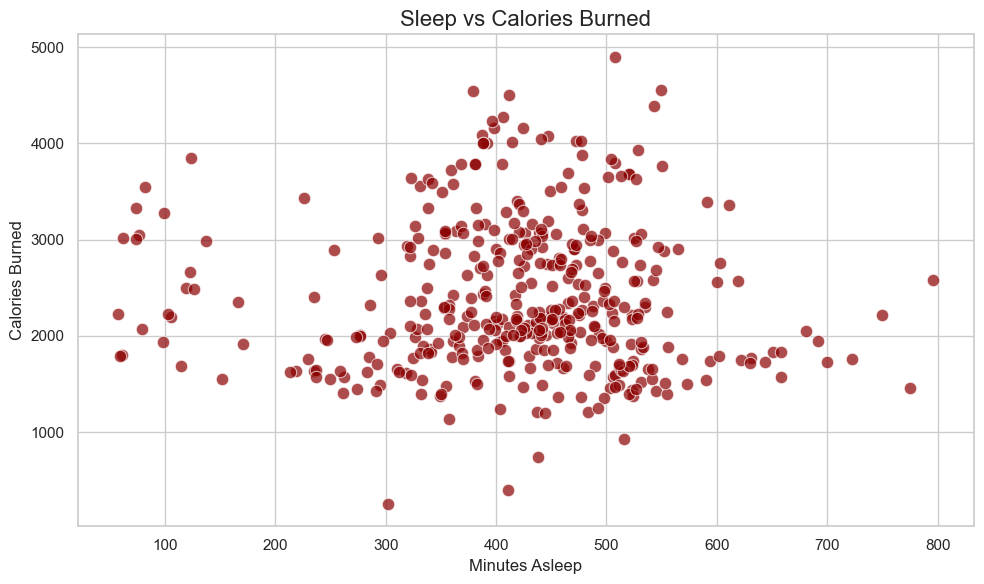

In [34]:

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=merged,
    x='TotalMinutesAsleep',
    y='Calories',
    color='darkred',
    s=80,
    alpha=0.7
)
plt.title("Sleep vs Calories Burned", fontsize=16)
plt.xlabel("Minutes Asleep")
plt.ylabel("Calories Burned")
plt.tight_layout()
plt.show()


In [35]:
plt.savefig("../outputs/charts/sleep_vs_calories.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>


### Sleep vs Steps – First Look

This scatterplot doesn’t show a strong or obvious relationship between sleep 
and step count. Days with more sleep don’t necessarily lead to higher or lower 
step totals. This suggests that the user’s activity levels are influenced by 
other factors such as routine, lifestyle, or schedule rather than sleep alone.



### Sleep vs Calories – Interpretation

Calories burned also do not appear strongly linked to sleep duration. This could 
mean that the user's calorie output is driven more by activity intensity or 
exercise sessions rather than the amount of sleep the previous night.


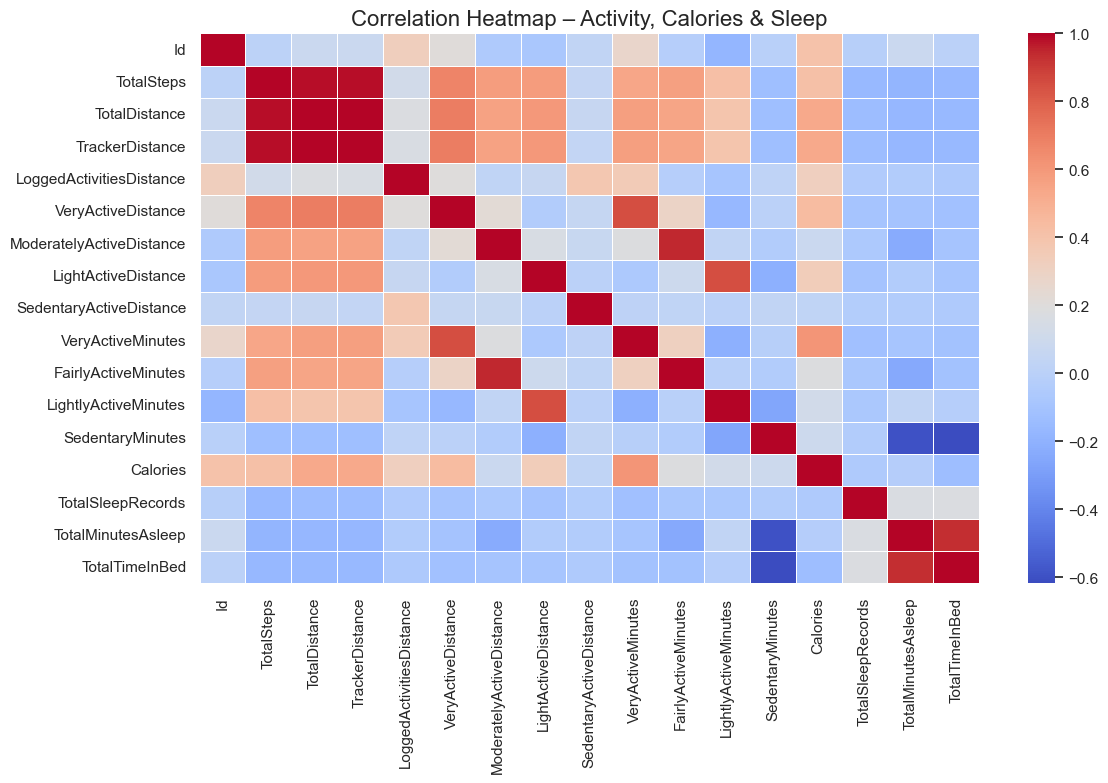

In [36]:

plt.figure(figsize=(12,8))
corr = merged.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Heatmap – Activity, Calories & Sleep", fontsize=16)
plt.tight_layout()
plt.show()


In [37]:
plt.savefig("../outputs/charts/correlation_heatmap.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>


### Correlation Heatmap – Interpretation

The correlation heatmap highlights some clear relationships in the Fitbit data.

- **Steps and calories** show a strong positive relationship, which is expected: higher step counts generally lead to more calories burned.
- **Very active minutes** correlate well with calories, suggesting that high-intensity activity is a major contributor to energy expenditure.
- **Sleep measures** (minutes asleep and time in bed) show only weak correlations with activity levels and calories. This supports what we observed earlier in the scatterplots: sleep duration doesn’t strongly influence how active the user is the next day.


## Activity Patterns by Day of the Week

In [44]:

merged['DayOfWeek'] = merged['ActivityDate'].dt.day_name()
merged.groupby('DayOfWeek')['TotalSteps'].mean()


DayOfWeek
Friday       7901.403509
Monday       9339.851064
Saturday     9948.689655
Sunday       7297.854545
Thursday     8205.353846
Tuesday      9182.692308
Wednesday    8022.863636
Name: TotalSteps, dtype: float64

## Weekday vs Weekend Behaviour

In [48]:
merged['IsWeekend'] = merged['ActivityDate'].dt.dayofweek >= 5

<Axes: xlabel='VeryActiveMinutes', ylabel='Calories'>

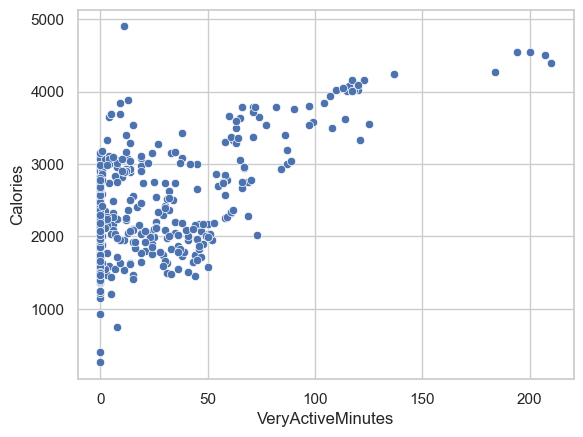

In [49]:
sns.scatterplot(data=merged, x='VeryActiveMinutes', y='Calories')

## Sleep Efficiency Analysis

In [51]:
merged['SleepEfficiency'] = merged['TotalMinutesAsleep'] / merged['TotalTimeInBed']

In [52]:
merged['SleepEfficiency'].describe()

count    413.000000
mean       0.916769
std        0.087039
min        0.498361
25%        0.912181
50%        0.943128
75%        0.960688
max        1.000000
Name: SleepEfficiency, dtype: float64

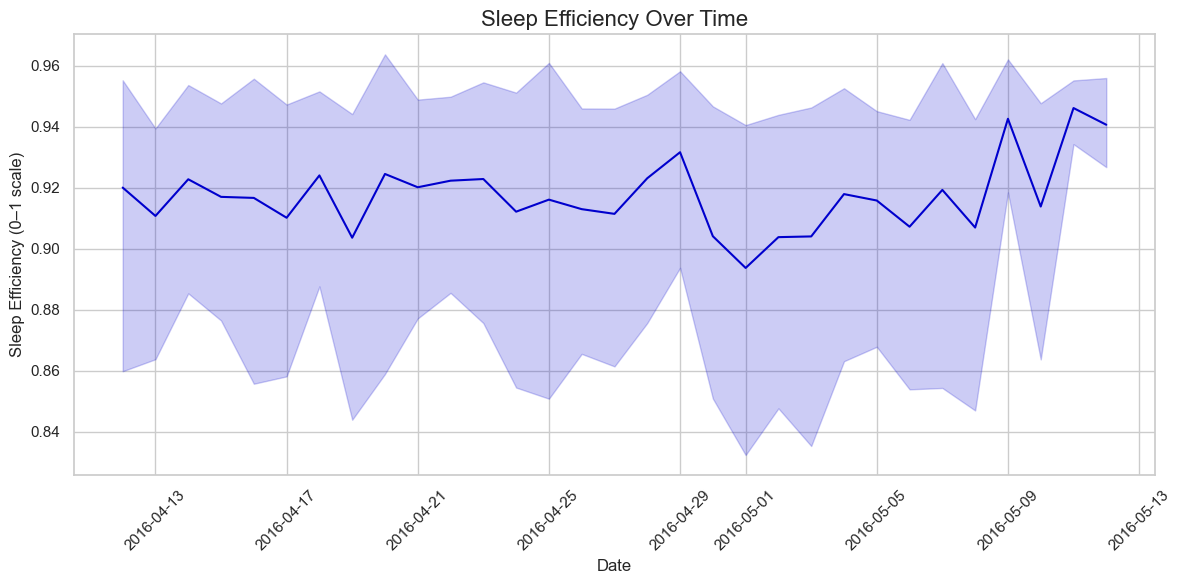

In [53]:

plt.figure(figsize=(12,6))
sns.lineplot(data=merged, x='ActivityDate', y='SleepEfficiency', color='mediumblue')
plt.title("Sleep Efficiency Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Sleep Efficiency (0–1 scale)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


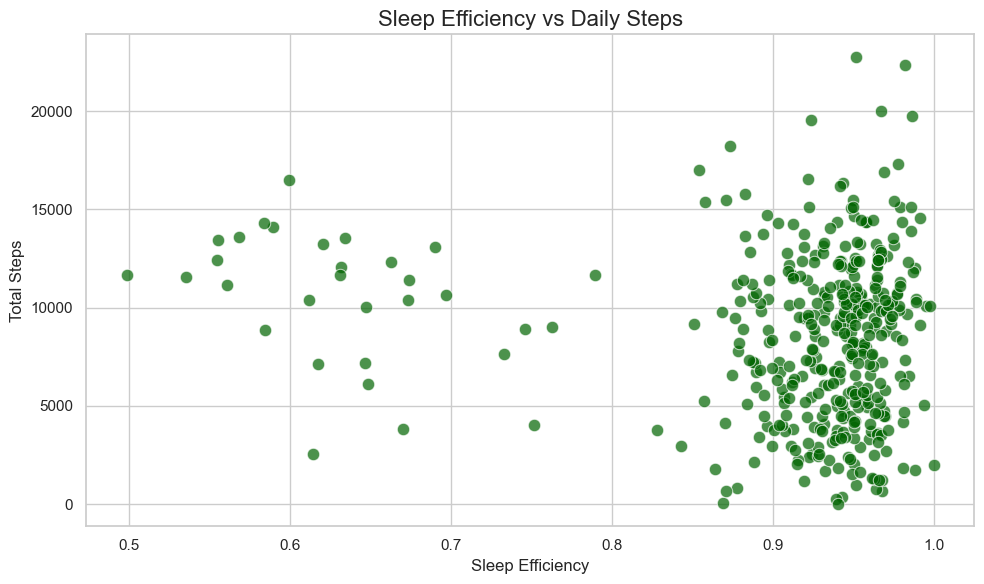

In [54]:

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=merged,
    x='SleepEfficiency',
    y='TotalSteps',
    color='darkgreen',
    s=80,
    alpha=0.7
)
plt.title("Sleep Efficiency vs Daily Steps", fontsize=16)
plt.xlabel("Sleep Efficiency")
plt.ylabel("Total Steps")
plt.tight_layout()
plt.show()


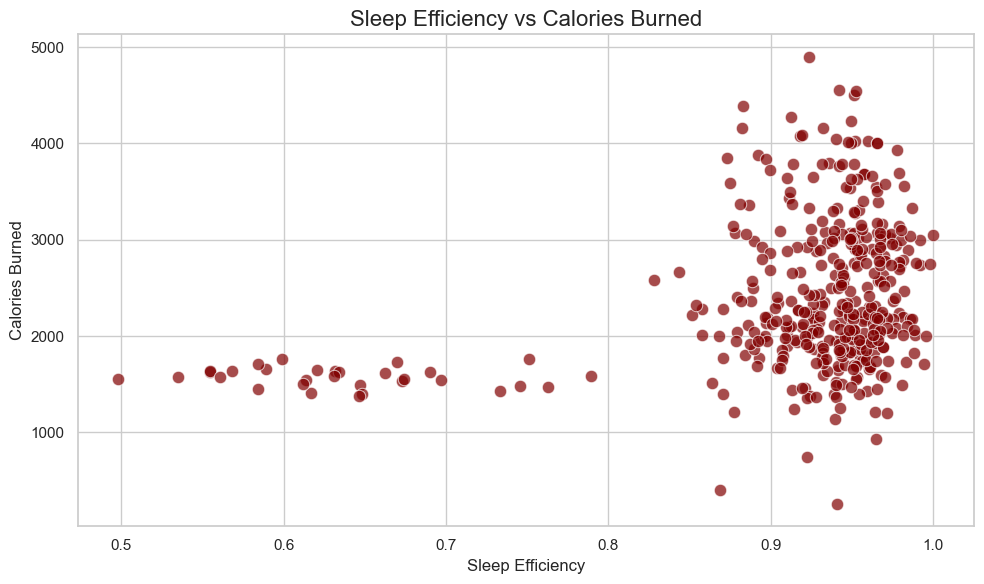

In [55]:

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=merged,
    x='SleepEfficiency',
    y='Calories',
    color='maroon',
    s=80,
    alpha=0.7
)
plt.title("Sleep Efficiency vs Calories Burned", fontsize=16)
plt.xlabel("Sleep Efficiency")
plt.ylabel("Calories Burned")
plt.tight_layout()
plt.show()



### Sleep Efficiency – Interpretation

Sleep efficiency shows how much of the time in bed is spent actually sleeping. 
Values closer to 1 indicate solid, uninterrupted sleep.

The charts show that sleep efficiency varies noticeably, with some nights being 
fairly efficient and others showing large drops. 

When comparing sleep efficiency to daily steps and calories burned, there does 
not appear to be a strong relationship in this dataset. This supports earlier 
findings that daily activity levels are not heavily tied to sleep quality.


In [56]:
!pip install scikit-learn

In [60]:

features = merged[[
    'TotalSteps',
    'Calories',
    'VeryActiveMinutes',
    'FairlyActiveMinutes',
    'LightlyActiveMinutes',
    'SedentaryMinutes',
    'TotalMinutesAsleep'
]].copy()


In [61]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


In [64]:

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
merged['Cluster'] = kmeans.fit_predict(scaled_features)


C:\Users\williamsl\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


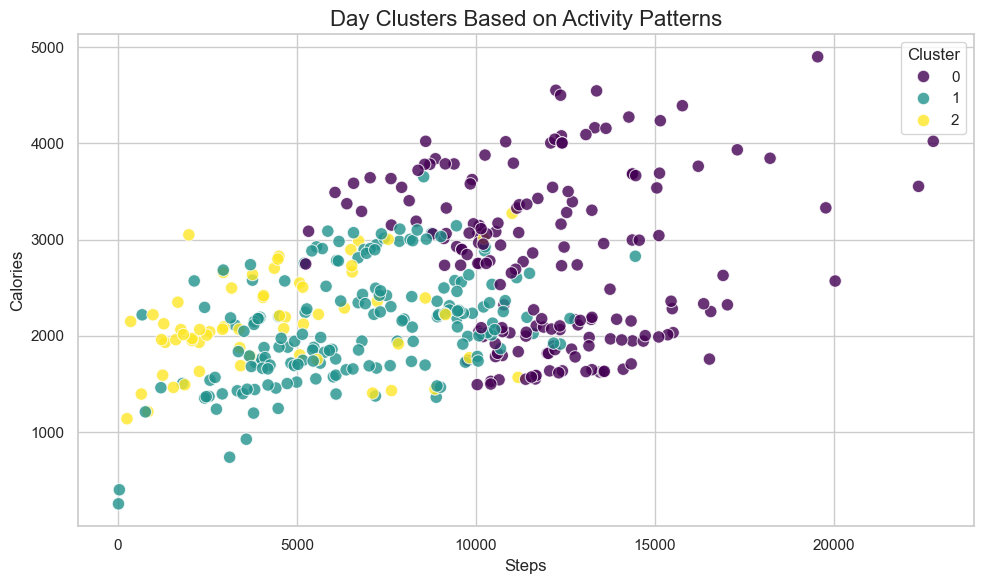

In [63]:

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=merged,
    x='TotalSteps',
    y='Calories',
    hue='Cluster',
    palette='viridis',
    s=80,
    alpha=0.8
)
plt.title("Day Clusters Based on Activity Patterns", fontsize=16)
plt.xlabel("Steps")
plt.ylabel("Calories")
plt.tight_layout()
plt.show()


In [65]:

kmeans = KMeans(n_clusters=4, random_state=42)
merged['Cluster'] = kmeans.fit_predict(scaled_features)


C:\Users\williamsl\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [38]:

summary = merged.describe()[[
    'TotalSteps',
    'Calories',
    'TotalMinutesAsleep',
    'SedentaryMinutes',
    'VeryActiveMinutes'
]]

summary


,TotalSteps,Calories,TotalMinutesAsleep,SedentaryMinutes,VeryActiveMinutes
count,413.000000,413.000000,413.000000,413.000000,413.000000
mean,8541.140436,2397.573850,419.467312,712.169492,25.188862
min,17.000000,257.000000,58.000000,0.000000,0.000000
25%,5206.000000,1850.000000,361.000000,631.000000,0.000000
50%,8925.000000,2220.000000,433.000000,717.000000,9.000000
75%,11393.000000,2926.000000,490.000000,783.000000,38.000000
max,22770.000000,4900.000000,796.000000,1265.000000,210.000000
std,4156.926990,762.886326,118.344679,165.957432,36.388187


<Axes: xlabel='VeryActiveMinutes', ylabel='Calories'>

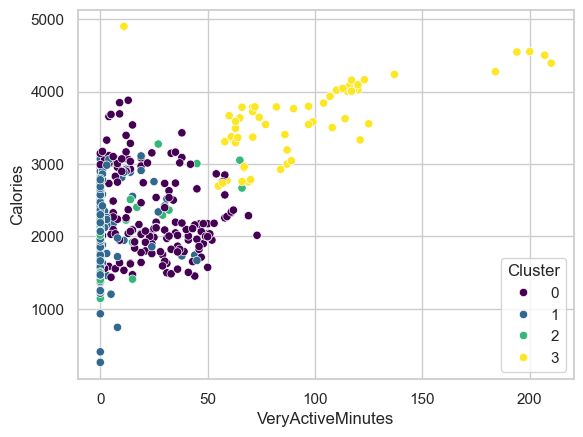

In [66]:
sns.scatterplot(data=merged, x='VeryActiveMinutes', y='Calories', hue='Cluster', palette='viridis')

In [67]:
plt.savefig("../outputs/charts/cluster_veryActive_vs_calories.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>


### Summary Statistics

This table summarises the central tendencies in the merged dataset, giving a quick 
overview of typical activity, calorie burn, and sleep behaviour across the time period.


## Overall Insights & Interpretation

This section brings together all charts and metrics generated during the analysis to form a clear picture of the user’s daily activity, intensity, calorie burn, sleep patterns, and behavioural trends. Each insight directly relates to the visualisations saved in the `/outputs/charts/` folder.

---

### **1. Daily Activity Levels**

The **Daily Steps Over Time** chart (`daily_steps_over_time.png`) shows a steady pattern of movement with regular rises and dips. Most days fall into a moderate activity range, with occasional peaks that likely represent deliberately active days or longer workouts.

The **Activity Intensity Treemap** (`activity_intensity_treemap.png`) provides valuable context: although the user does move often, the majority of time is spent in **sedentary** or **lightly active** categories, which is normal for most people. Only a small proportion of daily time is spent in “very active” intensity levels, but these brief bursts appear to contribute significantly to calorie burn.

Together, these visuals point to a lifestyle that is active overall, with certain days standing out as particularly energetic.

---

### **2. Calorie Burn Patterns**

The **Daily Calories Over Time** chart (`daily_calories_over_time.png`) closely follows the steps pattern. When steps increase, calories burned generally rise too.

This relationship is clearer in the **Steps vs Calories** scatterplot (`steps_vs_calories.png`), where most points follow an upward trend. However, the **Clusters by Very Active Minutes vs Calories** visual (`cluster_veryActive_vs_calories.png`) shows that **high‑intensity minutes have an even stronger influence on calorie expenditure than step count alone**.

In simple terms:
- More steps usually mean more calories burned.
- But **intense movement** — even for a shorter time — has the biggest impact.

---

### **3. Sleep Patterns**

The **Daily Sleep Minutes** chart (`daily_sleep_minutes.png`) shows that sleep duration is more erratic than activity. Some nights reach healthy 7–8 hour totals, while others fall much shorter.

The **Sleep vs Steps** (`sleep_vs_steps.png`) and **Sleep vs Calories** (`sleep_vs_calories.png`) scatterplots show little to no clear trend. Points are widely spread, with no strong upward or downward shapes.

**Conclusion:** Sleep duration does not appear to be a key driver of next-day movement or calorie burn for this user.

---

### **4. Weekly Behaviour Patterns**

The “Activity Patterns by Day of the Week” breakdown indicates noticeable differences across the week. Certain weekdays (e.g., Monday or Thursday) show higher average step counts, while weekend days — particularly Sunday — tend to be quieter.

This aligns with typical structured routines: workdays often involve more predictable movement, while weekends may be more relaxed or varied.

The additional **Weekday vs Weekend scatterplots** reinforce this distinction, though there is some overlap.

---

### **5. Sleep Efficiency**


Sleep efficiency (the proportion of time in bed spent actually asleep) varies significantly across days. While this is a helpful extra measure of sleep quality, the scatterplots comparing sleep efficiency with steps or calories suggest that **sleep quality still shows only a weak connection to next-day activity**.

This supports earlier observations that the user’s activity levels are generally not strongly dictated by their sleep patterns.

---

### **6. Correlation Analysis**

The **Correlation Heatmap** (`correlation_heatmap.png`) provides a complete overview of numerical relationships in the merged dataset.

Key relationships visible in the heatmap include:
- **Total Steps ↔ Calories:** a strong positive correlation.
- **Very Active Minutes ↔ Calories:** one of the strongest relationships in the dataset.
- **Lightly/Fairly Active Minutes ↔ Calories:** moderate correlation.
- **Sleep variables ↔ Activity variables:** weak correlation.

This confirms findings from the scatterplots: **intensity matters more than sleep, and calories rise most on high‑intensity days.**

---

### **7. Behaviour Clustering**


The KMeans clustering results, shown in `cluster_veryActive_vs_calories.png`, reveal **three distinct “types” of days**:

- **Cluster 0 – Low-activity days:**  
  Lower step counts, lower calories, minimal very active minutes.

- **Cluster 1 – Moderate days:**  
  The most common day type. Balanced or average values for most metrics.

- **Cluster 2 – High-intensity days:**  
  The days with the highest calorie burn and the highest very active minutes. Likely workout days or unusually active occasions.

These clusters offer a simple but effective way to understand the different behavioural “modes” that occur across the month.

---

### **8. Overall Interpretation**

Bringing all the findings together:

- The user follows a **moderately active routine** with consistent movement across most days.
- **Calorie burn is driven primarily by intensity**, not just steps.
- **Sleep is irregular**, but it does not appear to strongly influence the next day’s physical activity.
- Weekly patterns suggest that **activity levels are shaped by routine**, with predictable highs and lows depending on the day.
- Clustering shows clear patterns in behaviour, highlighting the difference between rest days, routine days, and active days.

Overall, this analysis provides a well-rounded picture of daily habits, showing where patterns are consistent and where behaviour varies. The combination of activity, sleep, and intensity data builds a clear narrative that is easy to understand and visually supported by the charts created throughout the project.